In [ ]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm

# Cargar dataset
train_df = pd.read_csv("train_final.csv")
test_df = pd.read_csv("test_final.csv")

X_train_raw = train_df['Headline_Text'].astype(str).tolist()
X_test_raw = test_df['Headline_Text'].astype(str).tolist()

In [ ]:
# Normalizar y mapear etiquetas
train_df['Category'] = train_df['Category'].astype(str).str.strip().str.capitalize()
test_df['Category'] = test_df['Category'].astype(str).str.strip().str.capitalize()

label_map = {"False": 0, "True": 1}
train_df['Category'] = train_df['Category'].map(label_map).fillna(0).astype(int)
test_df['Category'] = test_df['Category'].map(label_map).fillna(0).astype(int)

y_train = train_df['Category'].tolist()
y_test = test_df['Category'].tolist()

In [ ]:
# Tokenización
tokenizer = AutoTokenizer.from_pretrained("dccuchile/bert-base-spanish-wwm-cased")

X_train_enc = tokenizer(X_train_raw, padding=True, truncation=True, max_length=128)
X_test_enc = tokenizer(X_test_raw, padding=True, truncation=True, max_length=128)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/480k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

In [ ]:
# Dataset personalizado
class NewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(self.encodings[key][idx]) for key in self.encodings}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = NewsDataset(X_train_enc, y_train)
test_dataset = NewsDataset(X_test_enc, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

In [ ]:
# Modelo
model = AutoModelForSequenceClassification.from_pretrained(
    "dccuchile/bert-base-spanish-wwm-cased",
    num_labels=2
)

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not 

In [ ]:
# Entrenamiento con barra de progreso
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

import torch.nn as nn
from sklearn.metrics import f1_score

# Calcular pesos de clase según distribución en train_df
class_counts = train_df['Category'].value_counts()
total = len(train_df)
weights = [total/class_counts[0], total/class_counts[1]]
weights = torch.tensor(weights, dtype=torch.float).to(device)

loss_fn = nn.CrossEntropyLoss(weight=weights)

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

# Configuración de early stopping
patience = 4               # número de epochs sin mejora permitidos
best_f1 = 0.0              # mejor F1 observado
counter = 0                # contador de paciencia

for epoch in range(15):     # base de 5 epochs
    model.train()
    loop = tqdm(train_loader, leave=True)
    for batch in loop:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)

        logits = outputs.logits
        loss = loss_fn(logits, batch["labels"])

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        loop.set_description(f"Epoch {epoch+1}")
        loop.set_postfix(loss=loss.item())
    print(f"Epoch {epoch+1} completed !!!")

    # evaluación rápida en test para early stopping
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=-1)
            preds.extend(predictions.cpu().numpy())
            labels.extend(batch["labels"].cpu().numpy())

    f1 = f1_score(labels, preds, average="macro")
    print(f"Epoch {epoch+1} - F1 en validación: {f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        counter = 0
        print("Mejora detectada, guardando modelo temporal...")
        torch.save(model.state_dict(), "best_model.pt")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping activado: no hay mejora en F1.")
            break


Epoch 1: 100%|██████████| 170/170 [01:02<00:00,  2.74it/s, loss=0.000766]


Epoch 1 completed !!!
Epoch 1 - F1 en validación: 0.8037
Mejora detectada, guardando modelo temporal...


Epoch 2: 100%|██████████| 170/170 [01:01<00:00,  2.75it/s, loss=9.84e-5]


Epoch 2 completed !!!
Epoch 2 - F1 en validación: 0.8544
Mejora detectada, guardando modelo temporal...


Epoch 3: 100%|██████████| 170/170 [01:01<00:00,  2.75it/s, loss=9.01e-5]


...

Epoch 5 completed !!!
Epoch 5 - F1 en validación: 0.8545


Epoch 6: 100%|██████████| 170/170 [01:01<00:00,  2.77it/s, loss=0.000261]


Epoch 6 completed !!!
Epoch 6 - F1 en validación: 0.8465


Epoch 7: 100%|██████████| 170/170 [01:01<00:00,  2.76it/s, loss=0.00834]


Epoch 7 completed !!!
Epoch 7 - F1 en validación: 0.8391
Early stopping activado: no hay mejora en F1.


Evaluando: 100%|██████████| 43/43 [00:04<00:00,  8.82it/s]





Matriz de confusión:
 [[542  11]
 [ 47  78]]
Exactitud (Accuracy): 0.9144542772861357

Reporte de clasificación:

              precision    recall  f1-score   support

       False     0.9202    0.9801    0.9492       553
        True     0.8764    0.6240    0.7290       125

    accuracy                         0.9145       678
   macro avg     0.8983    0.8021    0.8391       678
weighted avg     0.9121    0.9145    0.9086       678


ROC-AUC: 0.9681


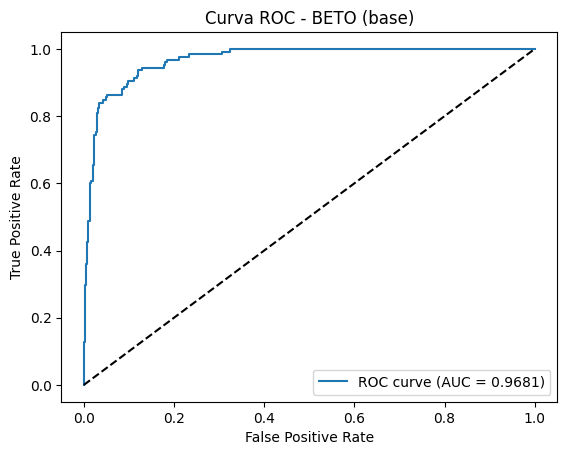

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

# Evaluación del modelo con barra de progreso
model.eval()
preds, labels, probs = [], [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluando", leave=True):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=-1)
        preds.extend(predictions.cpu().numpy())
        labels.extend(batch["labels"].cpu().numpy())
        # Probabilidad de clase positiva (True)
        prob_true = torch.softmax(logits, dim=-1)[:,1]
        probs.extend(prob_true.cpu().numpy())
print()
print()
# Matriz de confusión
cm = confusion_matrix(labels, preds)
print("\nMatriz de confusión:\n", cm)

# Exactitud global
print("Exactitud (Accuracy):", accuracy_score(labels, preds))

# Reporte detallado
print("\nReporte de clasificación:\n")
print(classification_report(labels, preds, target_names=["False","True"], digits=4))

# ROC-AUC
roc_auc = roc_auc_score(labels, probs)
print(f"\nROC-AUC: {roc_auc:.4f}")

# Curva ROC
fpr, tpr, _ = roc_curve(labels, probs)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - BETO (base)")
plt.legend(loc="lower right")

plt.savefig("curva_roc_beto_base.png", dpi=300, bbox_inches="tight")
plt.show()


Evaluando con probabilidades: 100%|██████████| 43/43 [00:04<00:00,  8.69it/s]





Umbral óptimo según F1: 0.0238
Matriz de confusión (umbral ajustado):
 [[535  18]
 [ 20 105]]
Exactitud (Accuracy): 0.943952802359882

Reporte de clasificación:

              precision    recall  f1-score   support

       False     0.9640    0.9675    0.9657       553
        True     0.8537    0.8400    0.8468       125

    accuracy                         0.9440       678
   macro avg     0.9088    0.9037    0.9062       678
weighted avg     0.9436    0.9440    0.9438       678


ROC-AUC: 0.9681


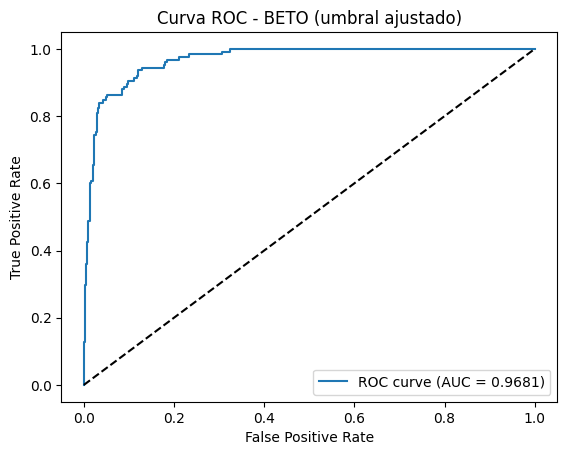

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_recall_curve, roc_auc_score, roc_curve
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# Obtener scores de probabilidad (softmax)
model.eval()
probs, labels = [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluando con probabilidades"):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        logits = outputs.logits
        # Probabilidad de clase positiva (True)
        prob_true = torch.softmax(logits, dim=-1)[:,1]
        probs.extend(prob_true.cpu().numpy())
        labels.extend(batch["labels"].cpu().numpy())

probs = np.array(probs)
labels = np.array(labels)

# Calcular curva Precision-Recall y encontrar umbral óptimo (máx F1)
precisions, recalls, thresholds = precision_recall_curve(labels, probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print()
print()
print(f"\nUmbral óptimo según F1: {best_threshold:.4f}")

# Evaluación con umbral ajustado
preds_adjusted = (probs >= best_threshold).astype(int)

cm = confusion_matrix(labels, preds_adjusted)
print("Matriz de confusión (umbral ajustado):\n", cm)
print("Exactitud (Accuracy):", accuracy_score(labels, preds_adjusted))
print("\nReporte de clasificación:\n")
print(classification_report(labels, preds_adjusted, target_names=["False","True"], digits=4))

# ROC-AUC
roc_auc = roc_auc_score(labels, probs)
print(f"\nROC-AUC: {roc_auc:.4f}")

# Curva ROC
fpr, tpr, _ = roc_curve(labels, probs)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - BETO (umbral ajustado)")
plt.legend(loc="lower right")
plt.show()


In [ ]:
# Cargar el mejor checkpoint guardado durante el entrenamiento
model.load_state_dict(torch.load("best_model.pt"))


model.save_pretrained("modelo_beto_final")
tokenizer.save_pretrained("modelo_beto_final")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('modelo_beto_final/tokenizer_config.json', 'modelo_beto_final/tokenizer.json')

In [ ]:
!zip -r modelo_beto_final.zip modelo_beto_final
from google.colab import files
files.download("modelo_beto_final.zip")


  adding: modelo_beto_final/ (stored 0%)
  adding: modelo_beto_final/tokenizer.json (deflated 71%)
  adding: modelo_beto_final/model.safetensors (deflated 7%)
  adding: modelo_beto_final/config.json (deflated 53%)
  adding: modelo_beto_final/tokenizer_config.json (deflated 45%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#para descomprimir modelo ya entrenado
!unzip modelo_beto_final.zip -d ./modelo_beto_final


In [ ]:
#cargar modelo y tokenizer
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model = AutoModelForSequenceClassification.from_pretrained("./modelo_beto_final")
tokenizer = AutoTokenizer.from_pretrained("./modelo_beto_final")
